<a href="https://colab.research.google.com/github/1RakshitPatil/Fraud-detection-and-premium-prediction-model/blob/main/modeldevelopment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Worksheet in Case Study question 2.xlsx - Fraud_Detection_decsion tree.csv')

In [3]:
print(f"Dataset Shape   : {df.shape}")             # Expected: (1000, 39)
print(f"Fraud (Y)       : {(df['fraud_reported']=='Y').sum()}")   # Expected: 247
print(f"Not Fraud (N)   : {(df['fraud_reported']=='N').sum()}")   # Expected: 753
print("\nFirst 5 rows:")
df.head()

Dataset Shape   : (1000, 39)
Fraud (Y)       : 247
Not Fraud (N)   : 753

First 5 rows:


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,10/17/2014,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,6/27/2006,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,9/6/2000,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,5/25/1990,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,6/6/2014,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


In [4]:
# Step A — Drop columns that are IDs, dates, or free-text (not useful for ML)
# All 5 column names confirmed present in your dataset ✅
DROP_COLS = [
    "policy_number",       # unique ID — not predictive
    "policy_bind_date",    # date string
    "incident_date",       # date string
    "incident_location",   # free text address
    "insured_zip",         # ZIP treated as number — misleading for ML
]
df.drop(columns=DROP_COLS, inplace=True, errors="ignore")
print(f"✅ Dropped {len(DROP_COLS)} non-predictive columns")

✅ Dropped 5 non-predictive columns


In [5]:
df.replace("?", np.nan, inplace=True)
print(f"✅ Replaced all '?' with NaN")

✅ Replaced all '?' with NaN


In [6]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in cat_cols:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])   # ✅ FIXED

for col in num_cols:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())    # ✅ FIXED

print(f"✅ Missing values remaining: {df.isna().sum().sum()}")

✅ Missing values remaining: 0


In [7]:
df["fraud_reported"] = (df["fraud_reported"] == "Y").astype(int)
print(f"✅ Target encoded — 1=Fraud, 0=Not Fraud")


✅ Target encoded — 1=Fraud, 0=Not Fraud


In [8]:
# ── CELL 4: FEATURE ENGINEERING ─────────────────────────────
# All source column names confirmed present in your dataset ✅
#   total_claim_amount, number_of_vehicles_involved, injury_claim,
#   property_claim, vehicle_claim, capital-gains, capital-loss, auto_year

df["claim_per_vehicle"]  = df["total_claim_amount"] / (df["number_of_vehicles_involved"] + 1)
df["injury_to_total"]    = df["injury_claim"]        / (df["total_claim_amount"] + 1)
df["property_to_total"]  = df["property_claim"]      / (df["total_claim_amount"] + 1)
df["vehicle_to_total"]   = df["vehicle_claim"]       / (df["total_claim_amount"] + 1)
df["net_capital"]        = df["capital-gains"]       + df["capital-loss"]
df["auto_age"]           = 2015 - df["auto_year"]    # auto_year range in dataset: ~2000–2015

print("✅ 6 new features created:")
print("   claim_per_vehicle, injury_to_total, property_to_total,")
print("   vehicle_to_total, net_capital, auto_age")


✅ 6 new features created:
   claim_per_vehicle, injury_to_total, property_to_total,
   vehicle_to_total, net_capital, auto_age


In [9]:
# ── CELL 5: ENCODE CATEGORICAL COLUMNS ──────────────────────

# ✅ BUG 2 FIXED: Added .copy() so X is an independent DataFrame.
#    Without .copy(), X is a view of df → assigning X[col] = ...
#    raises SettingWithCopyWarning and values may not save in Pandas 2.x
X = df.drop("fraud_reported", axis=1).copy()    # ✅ FIXED
y = df["fraud_reported"]

In [10]:
# Label-encode all remaining text / categorical columns
cat_features = X.select_dtypes(include="object").columns.tolist()
le_dict = {}

for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le   # keep encoder in case you need inverse_transform later

print(f"✅ Encoded {len(cat_features)} categorical columns")
print(f"✅ Final Feature Matrix Shape: {X.shape}")

✅ Encoded 17 categorical columns
✅ Final Feature Matrix Shape: (1000, 39)


In [11]:

# ── CELL 6: TRAIN / TEST SPLIT + SMOTE ──────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train Size : {X_train.shape[0]} rows")
print(f"Test Size  : {X_test.shape[0]} rows")

print(f"\nBefore SMOTE — Fraud in train: {y_train.sum()} / {len(y_train)}")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"After  SMOTE — Fraud in train: {y_train_res.sum()} / {len(y_train_res)}")

Train Size : 800 rows
Test Size  : 200 rows

Before SMOTE — Fraud in train: 198 / 800
After  SMOTE — Fraud in train: 602 / 1204


In [12]:
# ── CELL 7: TRAIN 4 MODELS ──────────────────────────────────
#
# ✅ BUG 3 & 4 FIXED: Logistic Regression is now wrapped in a Pipeline
#    (StandardScaler → LR). This ensures:
#      • Cell 8 CV: scaling happens inside every fold → correct CV scores
#      • Cell 12 single prediction: Pipeline scales automatically → correct result
#    Previously LR was trained on scaled data but CV and single-customer
#    prediction passed raw unscaled data → completely wrong outputs.

models = {
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=10,
                                                  random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                      max_depth=5, random_state=42),
    "Logistic Regression": Pipeline([                          # ✅ FIXED
        ("scaler", StandardScaler()),
        ("lr",     LogisticRegression(max_iter=1000, C=0.5, random_state=42))
    ]),
}

results = {}

for name, model in models.items():
    # All models use the same unscaled data; LR Pipeline handles scaling internally
    model.fit(X_train_res, y_train_res)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    auc    = roc_auc_score(y_test, y_prob)

    results[name] = {
        "model":  model,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "auc":    auc
    }
    print(f"{name:<25}  AUC = {auc:.4f}")

best_name = max(results, key=lambda k: results[k]["auc"])
best      = results[best_name]
print(f"\n✅ Best Model : {best_name}  (AUC = {best['auc']:.4f})")

Decision Tree              AUC = 0.7188
Random Forest              AUC = 0.8216
Gradient Boosting          AUC = 0.8128
Logistic Regression        AUC = 0.7985

✅ Best Model : Random Forest  (AUC = 0.8216)


In [14]:

# ── CELL 8: CROSS-VALIDATION ────────────────────────────────
# ✅ BUG 3 FIXED (via Pipeline): CV is now correct for all models.

best_model_obj = results[best_name]["model"]

cv_scores = cross_val_score(
    best_model_obj, X_train_res, y_train_res,
    cv=5, scoring="roc_auc", n_jobs=-1
)

print(f"5-Fold CV AUC Scores : {np.round(cv_scores, 4)}")
print(f"Mean AUC             : {cv_scores.mean():.4f}")
print(f"Std Dev              : {cv_scores.std():.4f}")





5-Fold CV AUC Scores : [0.899  0.9056 0.9583 0.9863 0.9797]
Mean AUC             : 0.9458
Std Dev              : 0.0368


In [15]:
# ── CELL 9: CLASSIFICATION REPORT ───────────────────────────

print(f"\nClassification Report — {best_name}")
print("=" * 50)
print(classification_report(
    y_test, best["y_pred"],
    target_names=["Not Fraud (0)", "Fraud (1)"]
))


Classification Report — Random Forest
               precision    recall  f1-score   support

Not Fraud (0)       0.87      0.87      0.87       151
    Fraud (1)       0.59      0.59      0.59        49

     accuracy                           0.80       200
    macro avg       0.73      0.73      0.73       200
 weighted avg       0.80      0.80      0.80       200



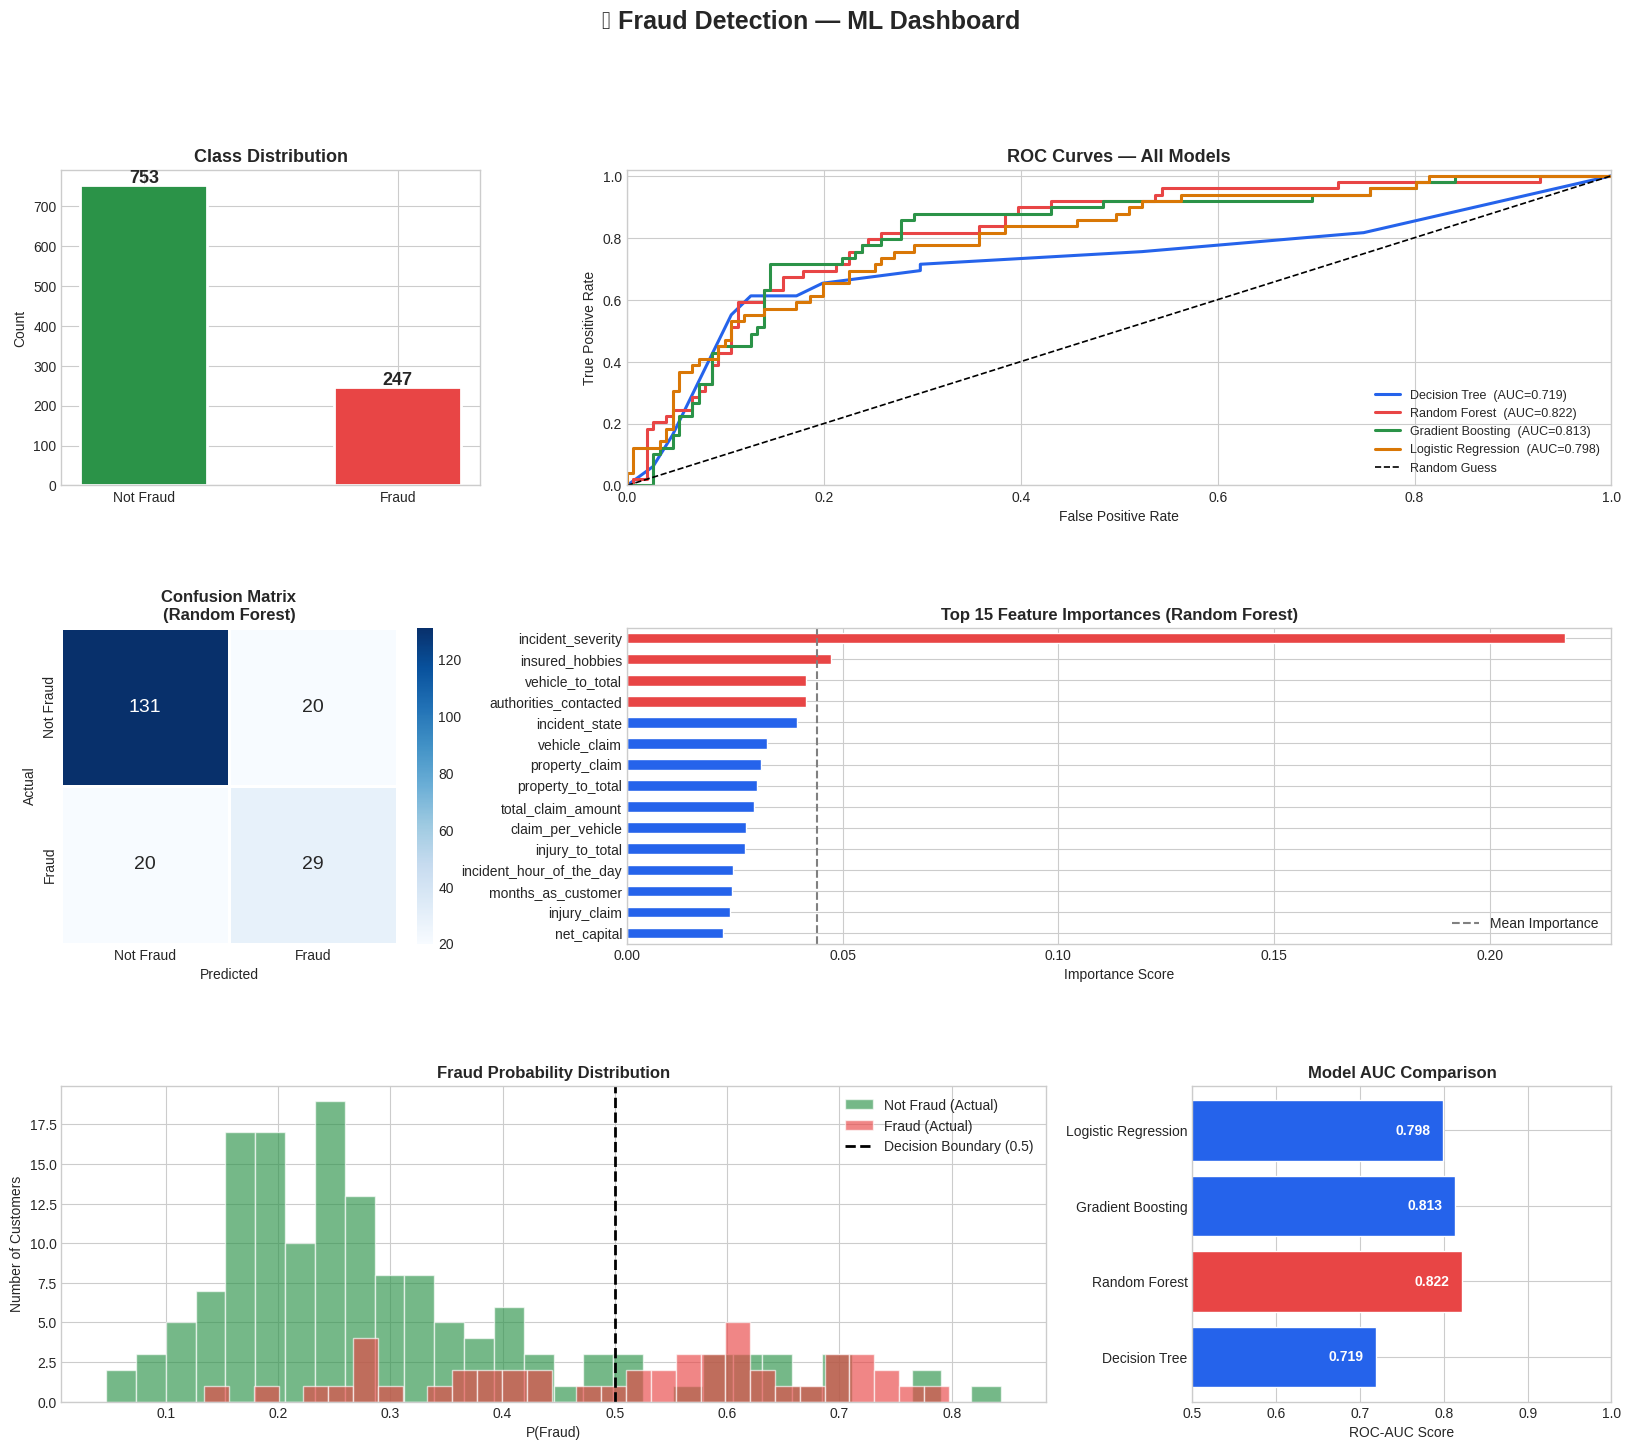

✅ Dashboard saved as fraud_detection_dashboard.png


In [16]:
# ── CELL 10: VISUALISATION DASHBOARD ────────────────────────

plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(20, 16))
fig.suptitle("🔍 Fraud Detection — ML Dashboard", fontsize=18, fontweight="bold", y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

RED    = "#E84545"
GREEN  = "#2B9348"
BLUE   = "#2563EB"
ORANGE = "#D97706"
PURPLE = "#7C3AED"

# --- Plot 1: Class Distribution ---
# ✅ BUG 6 FIXED: Counts computed from actual data (not hardcoded)
ax1 = fig.add_subplot(gs[0, 0])
counts = [int((df["fraud_reported"] == 0).sum()),   # 753 in your dataset
          int((df["fraud_reported"] == 1).sum())]   # 247 in your dataset
labels = ["Not Fraud", "Fraud"]
bars = ax1.bar(labels, counts, color=[GREEN, RED], edgecolor="white", linewidth=2, width=0.5)
for bar, val in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha="center", fontweight="bold", fontsize=13)
ax1.set_title("Class Distribution", fontweight="bold", fontsize=13)
ax1.set_ylabel("Count")

# --- Plot 2: ROC Curves ---
ax2 = fig.add_subplot(gs[0, 1:])
palette = [BLUE, RED, GREEN, ORANGE]
for (name, res), color in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax2.plot(fpr, tpr, label=f"{name}  (AUC={res['auc']:.3f})", color=color, lw=2.2)
ax2.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Guess")
ax2.set_title("ROC Curves — All Models", fontweight="bold", fontsize=13)
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(fontsize=9)
ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.02])

# --- Plot 3: Confusion Matrix ---
ax3 = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_test, best["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3,
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"],
            linewidths=2, linecolor="white", annot_kws={"size": 14})
ax3.set_title(f"Confusion Matrix\n({best_name})", fontweight="bold", fontsize=12)
ax3.set_ylabel("Actual"); ax3.set_xlabel("Predicted")

# --- Plot 4: Feature Importance ---
ax4 = fig.add_subplot(gs[1, 1:])
# Get the underlying estimator (handles both plain model and Pipeline)
_estimator = best_model_obj[-1] if isinstance(best_model_obj, Pipeline) else best_model_obj
if hasattr(_estimator, "feature_importances_"):
    feat_imp  = pd.Series(_estimator.feature_importances_, index=X.columns)
    top15     = feat_imp.nlargest(15).sort_values()
    colors_fi = [RED if v >= top15.quantile(0.75) else BLUE for v in top15]
    top15.plot(kind="barh", ax=ax4, color=colors_fi, edgecolor="white")
    ax4.axvline(top15.mean(), color="gray", linestyle="--", lw=1.5, label="Mean Importance")
    ax4.set_title(f"Top 15 Feature Importances ({best_name})", fontweight="bold", fontsize=12)
    ax4.set_xlabel("Importance Score")
    ax4.legend()

# --- Plot 5: Fraud Probability Distribution ---
# ✅ BUG 5 FIXED: Convert y_test to numpy array before boolean indexing.
#    y_test is a Pandas Series (original row index), best["y_prob"] is a
#    plain numpy array (0-based). Mixing them causes index misalignment.
ax5 = fig.add_subplot(gs[2, 0:2])
y_test_arr = y_test.values                              # ✅ FIXED
ax5.hist(best["y_prob"][y_test_arr == 0], bins=30, alpha=0.65,
         label="Not Fraud (Actual)", color=GREEN, edgecolor="white")
ax5.hist(best["y_prob"][y_test_arr == 1], bins=30, alpha=0.65,
         label="Fraud (Actual)", color=RED, edgecolor="white")
ax5.axvline(0.5, color="black", linestyle="--", lw=2, label="Decision Boundary (0.5)")
ax5.set_title("Fraud Probability Distribution", fontweight="bold", fontsize=12)
ax5.set_xlabel("P(Fraud)")
ax5.set_ylabel("Number of Customers")
ax5.legend()

# --- Plot 6: AUC Comparison Bar ---
ax6 = fig.add_subplot(gs[2, 2])
names_list = list(results.keys())
aucs_list  = [results[n]["auc"] for n in names_list]
bar_colors = [RED if n == best_name else BLUE for n in names_list]
bars6 = ax6.barh(names_list, aucs_list, color=bar_colors, edgecolor="white")
for bar, auc in zip(bars6, aucs_list):
    ax6.text(auc - 0.015, bar.get_y() + bar.get_height()/2,
             f"{auc:.3f}", va="center", ha="right",
             color="white", fontweight="bold", fontsize=10)
ax6.set_xlim([0.5, 1.0])
ax6.set_title("Model AUC Comparison", fontweight="bold", fontsize=12)
ax6.set_xlabel("ROC-AUC Score")

plt.savefig("fraud_detection_dashboard.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Dashboard saved as fraud_detection_dashboard.png")

In [17]:
output_df = X_test.copy()
output_df["Actual_Fraud"]       = y_test.values
output_df["Fraud_Probability"]  = np.round(best["y_prob"], 4)
output_df["Predicted_Fraud"]    = best["y_pred"]
output_df["Risk_Level"]         = pd.cut(
    output_df["Fraud_Probability"],
    bins=[0, 0.30, 0.60, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print("Top 10 Customers — Highest Fraud Probability:")
print("-" * 55)
top10 = output_df[["Fraud_Probability", "Risk_Level", "Actual_Fraud"]] \
        .sort_values("Fraud_Probability", ascending=False).head(10)
print(top10.to_string())

output_df[["Fraud_Probability", "Risk_Level", "Predicted_Fraud", "Actual_Fraud"]] \
    .to_csv("customer_fraud_probabilities.csv")
print("\n✅ Saved → customer_fraud_probabilities.csv")

Top 10 Customers — Highest Fraud Probability:
-------------------------------------------------------
     Fraud_Probability Risk_Level  Actual_Fraud
625             0.8440  High Risk             0
817             0.7974  High Risk             1
56              0.7857  High Risk             0
151             0.7839  High Risk             0
288             0.7636  High Risk             1
494             0.7480  High Risk             1
938             0.7354  High Risk             1
261             0.7238  High Risk             1
587             0.7218  High Risk             1
927             0.7108  High Risk             1

✅ Saved → customer_fraud_probabilities.csv


In [20]:

# ── CELL 12: PREDICT A SINGLE NEW CUSTOMER
single_customer = X_test.iloc[[0]]   # ← replace with your own customer row

fraud_prob = best_model_obj.predict_proba(single_customer)[0][1]

print("=" * 50)
print("      SINGLE CUSTOMER FRAUD PREDICTION")
print("=" * 50)
print(f"  Fraud Probability  :  {fraud_prob:.4f}  ({fraud_prob*100:.2f}%)")

if fraud_prob >= 0.60:
    print("  Risk Level         :  🔴 HIGH RISK — Likely Fraud")
elif fraud_prob >= 0.30:
    print("  Risk Level         :  🟡 MEDIUM RISK — Monitor Closely")
else:
    print("  Risk Level         :  🟢 LOW RISK — Unlikely Fraud")

print(f"  Actual Label       :  {'FRAUD' if y_test.iloc[0]==1 else 'NOT FRAUD'}")
print("=" * 50)

      SINGLE CUSTOMER FRAUD PREDICTION
  Fraud Probability  :  0.1772  (17.72%)
  Risk Level         :  🟢 LOW RISK — Unlikely Fraud
  Actual Label       :  NOT FRAUD


In [21]:
#FINAL SUMMARY

print("\n" + "=" * 50)
print("           ✅ PIPELINE COMPLETE")
print("=" * 50)
print(f"  Best Model     :  {best_name}")
print(f"  Test AUC       :  {best['auc']:.4f}")
print(f"  CV AUC (Mean)  :  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Test Accuracy  :  {(best['y_pred'] == y_test.values).mean()*100:.2f}%")
print("=" * 50)
print("  Output Files:")
print("    • fraud_detection_dashboard.png")
print("    • customer_fraud_probabilities.csv")
print("=" * 50)


           ✅ PIPELINE COMPLETE
  Best Model     :  Random Forest
  Test AUC       :  0.8216
  CV AUC (Mean)  :  0.9458 ± 0.0368
  Test Accuracy  :  80.00%
  Output Files:
    • fraud_detection_dashboard.png
    • customer_fraud_probabilities.csv
